In [1]:
%load_ext autoreload
%autoreload 2
import sys
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import confusion_matrix

sys.path.insert(0, '..')  # dataset.py lives one level up, shared across sector/industry notebooks
import dataset
import xgb_train

from investalyze.analysis import encodings
from investalyze.ingest import storage

plt.rcParams['figure.dpi'] = 130


In [2]:
TICKERS = 5000  # list[str] of specific tickers, int for a random sample of that many, or None for all
UNIVERSE = None  # name of a universe saved by the screener app (data/universes/<name>.csv); overrides TICKERS when set
EXCLUDE_TICKERS = []  # tickers to always leave out, regardless of TICKERS or UNIVERSE

LABEL_COLUMN = 'Industry'  # 'Sector' or 'Industry', from the companies table

SEED = 0  # used when TICKERS is an int, and when VALID_METHOD is 'random'
WINDOW_LENGTH = 60
STRIDE = 40

VALID_FRAC = 0.3
VALID_METHOD = 'random'  # 'recent' = time-based (no leakage) / 'random' = random per-window
TEST_N = 2  # always recent: the last N windows of each ticker

ENCODER = encodings.RebaseTo1  # swap by hand: RebaseTo100 / RebaseTo1 / encodings.zscore / encodings.minmax

N_ESTIMATORS = 500  # boosting rounds (upper bound; early stopping picks the best)
MAX_DEPTH = 12
LEARNING_RATE = 0.25
EARLY_STOPPING_ROUNDS = 10  # stop if valid mlogloss hasn't improved in this many rounds
N_JOBS = -1


In [3]:
DATA_ROOT = Path('../../data')

con = storage.connect(DATA_ROOT, read_only=True)
if UNIVERSE is not None:
    tickers = [t for t in dataset.load_universe(UNIVERSE, DATA_ROOT) if t not in EXCLUDE_TICKERS]
elif isinstance(TICKERS, int):
    tickers = dataset.sample_tickers(con, TICKERS, seed=SEED, exclude=EXCLUDE_TICKERS)
else:
    tickers = TICKERS
series = dataset.get_ohlcv_series(con, tickers, exclude=EXCLUDE_TICKERS)
ticker_labels = dataset.get_ticker_labels(con, LABEL_COLUMN)
con.close()
print('tickers used', tickers if tickers is not None else 'ALL')

channels, meta = dataset.build_windows(series, window_length=WINDOW_LENGTH, stride=STRIDE)
channels, meta = dataset.attach_labels(channels, meta, ticker_labels)
n_tickers, n_labels = meta['Ticker'].nunique(), meta['label'].nunique()
print(f"windows {meta.shape[0]} across {n_tickers} tickers and {n_labels} industrys")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

tickers used ['A', 'AA', 'AACB', 'AACG', 'AACI', 'AACOU', 'AACPU', 'AAEQ', 'AAL', 'AAME', 'AAMI', 'AAON', 'AAP', 'AAPG', 'AAPL', 'AAPW', 'AARD', 'AAT', 'AB', 'ABBV', 'ABCB', 'ABCL', 'ABEO', 'ABEV', 'ABLD', 'ABLG', 'ABLV', 'ABNB', 'ABNG', 'ABOS', 'ABOT', 'ABR-PE', 'ABSI', 'ABT', 'ABTS', 'ABUF', 'ABUS', 'ABVC', 'ABVE', 'ABVEW', 'ABVX', 'ABXB', 'ABXL', 'ACA', 'ACAA', 'ACAAU', 'ACAD', 'ACB', 'ACCL', 'ACCS', 'ACDC', 'ACEL', 'ACEP', 'ACFN', 'ACGCU', 'ACGL', 'ACGLN', 'ACGLO', 'ACGR', 'ACH', 'ACHR', 'ACIU', 'ACIW', 'ACLO', 'ACLX', 'ACM', 'ACN', 'ACNT', 'ACOG', 'ACON', 'ACONW', 'ACP-PA', 'ACR-PD', 'ACRS', 'ACT', 'ACTS', 'ACTU', 'ACU', 'ACV', 'ACVA', 'AD', 'ADAC', 'ADACU', 'ADAG', 'ADAMG', 'ADAMI', 'ADAMM', 'ADAMN', 'ADAMZ', 'ADC-PA', 'ADGM', 'ADM', 'ADMA', 'ADNT', 'ADP', 'ADPT', 'ADSE', 'ADSEW', 'ADTN', 'ADUR', 'ADV', 'ADX', 'AEAQ', 'AEAQU', 'AEBI', 'AEC', 'AEE', 'AEF', 'AEFC', 'AEG', 'AEHR', 'AEIS', 'AEM', 'AEMD', 'AENT', 'AEO', 'AEON', 'AEP', 'AER', 'AERT', 'AERTW', 'AEVA', 'AEXA', 'AFB', 'AF

In [4]:
train_mask, valid_mask, test_mask = dataset.split_windows(
    meta, valid_frac=VALID_FRAC, valid_method=VALID_METHOD, test_n=TEST_N, seed=SEED
)

labels, class_names = dataset.encode_labels(meta, train_mask, label_col='label')
n_classes = len(class_names)

print('train windows', int(train_mask.sum()), 'valid windows', int(valid_mask.sum()), 'test windows', int(test_mask.sum()))
pd.Series(labels[train_mask]).value_counts().sort_index()


train windows 229704 valid windows 98415 test windows 7028


0         2
1      1157
2      4084
3       733
4       736
       ... 
149    3781
150    1098
151     935
152     351
153     723
Name: count, Length: 154, dtype: int64

In [5]:
X = dataset.encode_windows(channels, ENCODER)
X_flat = dataset.flatten_windows(X)
X_train, y_train = X_flat[train_mask], labels[train_mask]
X_valid, y_valid = X_flat[valid_mask], labels[valid_mask]
X_test, y_test = X_flat[test_mask], labels[test_mask]

weights = dataset.class_weights(y_train, n_classes)
sample_weight = weights[y_train]


In [6]:
clf = xgb.XGBClassifier(
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    learning_rate=LEARNING_RATE,
    tree_method='hist',
    early_stopping_rounds=EARLY_STOPPING_ROUNDS,
    eval_metric='mlogloss',
    n_jobs=N_JOBS,
)
clf.fit(X_train, y_train, sample_weight=sample_weight, eval_set=[(X_valid, y_valid)], verbose=True)
print('best iteration', clf.best_iteration, '/', N_ESTIMATORS)


[0]	validation_0-mlogloss:5.08954
[1]	validation_0-mlogloss:5.03641
[2]	validation_0-mlogloss:4.99471
[3]	validation_0-mlogloss:4.95593
[4]	validation_0-mlogloss:4.92080
[5]	validation_0-mlogloss:4.88859
[6]	validation_0-mlogloss:4.85867
[7]	validation_0-mlogloss:4.83098
[8]	validation_0-mlogloss:4.80428
[9]	validation_0-mlogloss:4.78028
[10]	validation_0-mlogloss:4.75747
[11]	validation_0-mlogloss:4.73614
[12]	validation_0-mlogloss:4.71643
[13]	validation_0-mlogloss:4.69652
[14]	validation_0-mlogloss:4.67946
[15]	validation_0-mlogloss:4.66223
[16]	validation_0-mlogloss:4.64707
[17]	validation_0-mlogloss:4.63052
[18]	validation_0-mlogloss:4.61618
[19]	validation_0-mlogloss:4.60199
[20]	validation_0-mlogloss:4.58841
[21]	validation_0-mlogloss:4.57597
[22]	validation_0-mlogloss:4.56391
[23]	validation_0-mlogloss:4.55254
[24]	validation_0-mlogloss:4.54267
[25]	validation_0-mlogloss:4.53369
[26]	validation_0-mlogloss:4.52502
[27]	validation_0-mlogloss:4.51709
[28]	validation_0-mlogloss:4.5

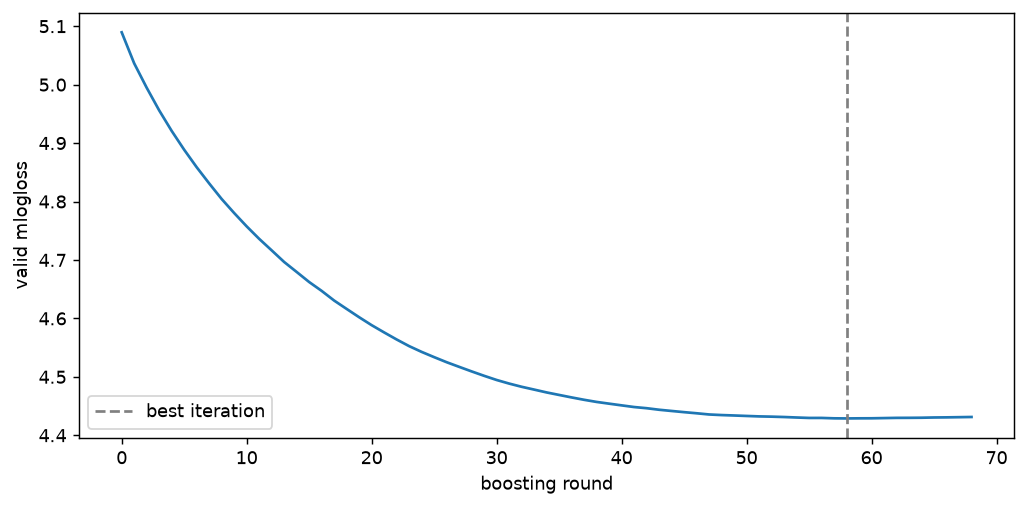

In [7]:
valid_logloss = clf.evals_result()['validation_0']['mlogloss']
plt.figure(figsize=(8, 4))
plt.plot(valid_logloss)
plt.axvline(clf.best_iteration, color='gray', linestyle='--', label='best iteration')
plt.xlabel('boosting round')
plt.ylabel('valid mlogloss')
plt.legend()
plt.tight_layout()
plt.show()


valid accuracy=0.119  macro-accuracy=0.015


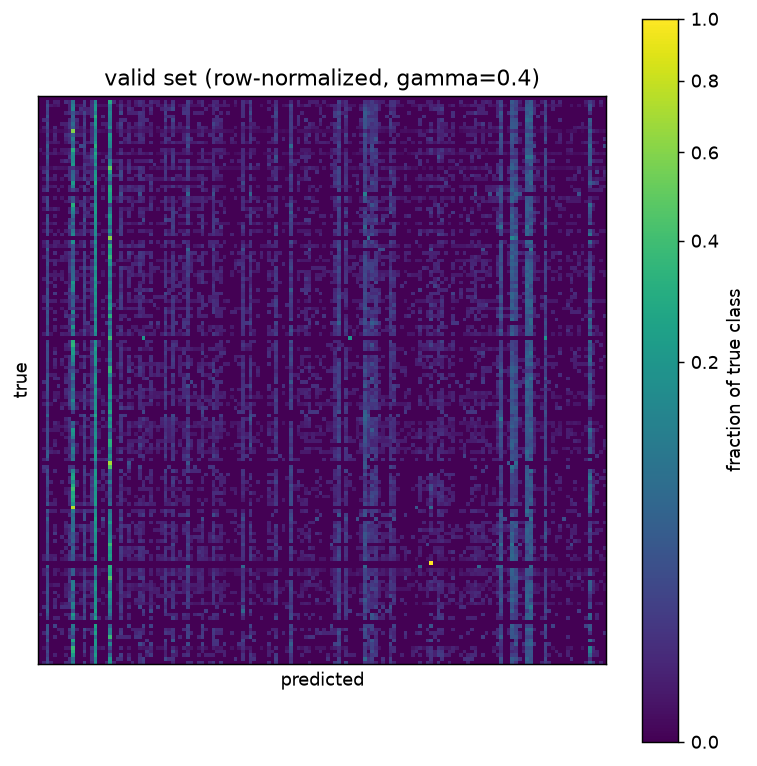

In [8]:
valid_preds = clf.predict(X_valid)
valid_true = y_valid
valid_macro_acc = xgb_train.macro_accuracy(valid_preds, valid_true, n_classes)
print(f'valid accuracy={(valid_preds == valid_true).mean():.3f}  macro-accuracy={valid_macro_acc:.3f}')

cm_valid = confusion_matrix(valid_true, valid_preds, labels=range(n_classes))
row_sums = cm_valid.sum(axis=1, keepdims=True)
cm_valid_norm = np.divide(cm_valid, row_sums, out=np.zeros_like(cm_valid, dtype=float), where=row_sums != 0)

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(cm_valid_norm, cmap='viridis', norm=mcolors.PowerNorm(gamma=0.4, vmin=0, vmax=1), interpolation='nearest')
if n_classes <= 40:
    ax.set_xticks(range(n_classes))
    ax.set_xticklabels(class_names, rotation=90)
    ax.set_yticks(range(n_classes))
    ax.set_yticklabels(class_names)
else:
    ax.set_xticks([])
    ax.set_yticks([])
ax.set_xlabel('predicted')
ax.set_ylabel('true')
ax.set_title('valid set (row-normalized, gamma=0.4)')
plt.colorbar(im, label='fraction of true class')
plt.tight_layout()
plt.show()


In [9]:
cm_valid_offdiag = cm_valid.copy()
np.fill_diagonal(cm_valid_offdiag, 0)
i_idx, j_idx = np.nonzero(cm_valid_offdiag)
counts = cm_valid_offdiag[i_idx, j_idx]
order = np.argsort(-counts)[:15]
valid_pairs = [(class_names[i], class_names[j], int(c)) for i, j, c in zip(i_idx[order], j_idx[order], counts[order])]
valid_pairs


[('Asset Management', 'Banks - Regional', 1093),
 ('Banks - Regional', 'Asset Management', 963),
 ('Software - Application', 'Biotechnology', 635),
 ('Utilities - Regulated Electric', 'Asset Management', 596),
 ('Asset Management', 'Utilities - Regulated Electric', 562),
 ('Software - Infrastructure', 'Biotechnology', 455),
 ('Specialty Industrial Machinery', 'Banks - Regional', 423),
 ('Medical Devices', 'Biotechnology', 382),
 ('Drug Manufacturers - Specialty & Generic', 'Biotechnology', 381),
 ('Specialty Chemicals', 'Banks - Regional', 361),
 ('REIT - Mortgage', 'Asset Management', 361),
 ('Aerospace & Defense', 'Banks - Regional', 333),
 ('Software - Application', 'Banks - Regional', 326),
 ('Banks - Regional', 'Biotechnology', 318),
 ('Insurance - Property & Casualty', 'Banks - Regional', 304)]

test accuracy=0.125  macro-accuracy=0.015


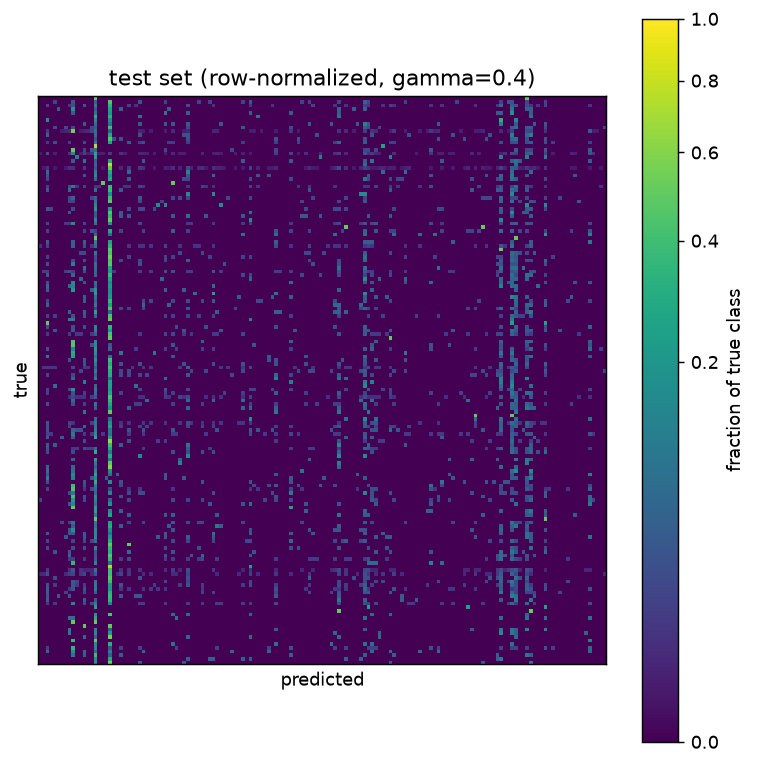

In [10]:
preds, y_true = clf.predict(X_test), y_test
test_acc = (preds == y_true).mean()
test_macro_acc = xgb_train.macro_accuracy(preds, y_true, n_classes)
print(f'test accuracy={test_acc:.3f}  macro-accuracy={test_macro_acc:.3f}')

cm = confusion_matrix(y_true, preds, labels=range(n_classes))
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(cm_norm, cmap='viridis', norm=mcolors.PowerNorm(gamma=0.4, vmin=0, vmax=1), interpolation='nearest')
if n_classes <= 40:
    ax.set_xticks(range(n_classes))
    ax.set_xticklabels(class_names, rotation=90)
    ax.set_yticks(range(n_classes))
    ax.set_yticklabels(class_names)
else:
    ax.set_xticks([])
    ax.set_yticks([])
ax.set_xlabel('predicted')
ax.set_ylabel('true')
ax.set_title('test set (row-normalized, gamma=0.4)')
plt.colorbar(im, label='fraction of true class')
plt.tight_layout()
plt.show()


In [11]:
cm_offdiag = cm.copy()
np.fill_diagonal(cm_offdiag, 0)
i_idx, j_idx = np.nonzero(cm_offdiag)
counts = cm_offdiag[i_idx, j_idx]
order = np.argsort(-counts)[:15]
pairs = [(class_names[i], class_names[j], int(c)) for i, j, c in zip(i_idx[order], j_idx[order], counts[order])]
pairs


[('Software - Application', 'Biotechnology', 106),
 ('Software - Infrastructure', 'Biotechnology', 80),
 ('Banks - Regional', 'Asset Management', 74),
 ('Medical Devices', 'Biotechnology', 62),
 ('Asset Management', 'Banks - Regional', 51),
 ('REIT - Mortgage', 'Asset Management', 49),
 ('Other Industrial Metals & Mining', 'Biotechnology', 44),
 ('Capital Markets', 'Biotechnology', 43),
 ('Information Technology Services', 'Biotechnology', 40),
 ('Aerospace & Defense', 'Biotechnology', 39),
 ('Internet Content & Information', 'Biotechnology', 38),
 ('Biotechnology', 'Software - Application', 38),
 ('Drug Manufacturers - Specialty & Generic', 'Biotechnology', 38),
 ('Asset Management', 'Biotechnology', 36),
 ('Biotechnology', 'Banks - Regional', 33)]

In [12]:
def worst_predicted(cm_offdiag, top=10):
    fp_counts = cm_offdiag.sum(axis=0)  # column sums: how often each class is wrongly predicted
    n_sources = (cm_offdiag > 0).sum(axis=0)  # distinct true classes wrongly predicted as this one
    order = np.argsort(-fp_counts)[:top]
    return order, fp_counts, n_sources


for name, offdiag in [('valid', cm_valid_offdiag), ('test', cm_offdiag)]:
    order, fp_counts, n_sources = worst_predicted(offdiag)
    print(f'{name}:')
    for idx in order:
        pct_sources = n_sources[idx] / n_classes * 100
        print(
            f'  {class_names[idx]:<28}  wrongly predicted {int(fp_counts[idx])} times, '
            f'from {int(n_sources[idx])} different classes ({pct_sources:.1f}% of all classes)'
        )
    print()


valid:
  Banks - Regional              wrongly predicted 14709 times, from 149 different classes (96.8% of all classes)
  Biotechnology                 wrongly predicted 12569 times, from 149 different classes (96.8% of all classes)
  Asset Management              wrongly predicted 9393 times, from 142 different classes (92.2% of all classes)
  Specialty Chemicals           wrongly predicted 3627 times, from 143 different classes (92.9% of all classes)
  Specialty Industrial Machinery  wrongly predicted 3512 times, from 144 different classes (93.5% of all classes)
  Software - Application        wrongly predicted 3285 times, from 143 different classes (92.9% of all classes)
  Utilities - Regulated Electric  wrongly predicted 3025 times, from 132 different classes (85.7% of all classes)
  Semiconductors                wrongly predicted 2095 times, from 144 different classes (93.5% of all classes)
  Aerospace & Defense           wrongly predicted 2034 times, from 144 different classes (9